# **Topological Analysis of Networks**

# Import Libraries and Configurations

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
# import rpy2.robjects as ro
from networkx.algorithms import bipartite
# from rpy2.robjects import conversion, pandas2ri
# from rpy2.robjects.packages import importr

# Import R's bipartite package
# bipartite_r = importr('bipartite')

# Add project root to Python's path
sys.path.append(os.path.abspath(os.path.join('..')))

from config import (
    NETWORK_DATA_DIRS,
    NETWORK_FILES,
)

# Metrics calculated in the individual analysis
METRICS = {
    'bipartite': [
        'betweenness_centrality', 
        'closeness_centrality', 
        'degree_centrality', 
        'redundancy_coefficient',
    ],
    'tripartite': [
        'pathway_reach',
        'functional_impact',
    ],
}

# Bipartite Networks

## Functions

### Creation of Network Object

In [2]:
def create_bipartite_network(edges_df, nodes_df):
    # Create the network using an edge list
    B = nx.from_pandas_edgelist(
        df=edges_df,
        source='source',
        target='target',
        edge_attr=True,
    )

    # Assign partition attribute
    partitions = list(nodes_df['type'].unique())
    attr_dict = nodes_df.set_index('id')['type'].to_dict()
    nx.set_node_attributes(G=B, values=attr_dict, name='partition')

    # Define the partition sets
    partition_1 = {
        n for n, d in B.nodes(data=True) 
        if d['partition'] == partitions[0]
    }
    partition_2 = set(B) - partition_1

    # Set the bipartite flag
    nx.set_node_attributes(
        G=B,
        values=(
            {n: 0 for n in partition_1} 
            | {n: 1 for n in partition_2}
        ),
        name='bipartite',
    )

    return B

### Topological Analysis

#### Module Detection

In [3]:
def build_biadjacency_matrix(B):
    # Identify the two partitions
    rows = {
        n for n, d in B.nodes(data=True) 
        if d['bipartite'] == 0
    }
    cols = set(B) - rows

    # Sort the sets of rows and columns by the names of the nodes
    rows = sorted(rows)
    cols = sorted(cols)

    # Build the biadjacency matrix
    B_matrix = bipartite.biadjacency_matrix(
        B, row_order=rows, column_order=cols
    )

    # Transform the biadjacency matrix into a DataFrame
    matrix_df= pd.DataFrame(
        data=B_matrix.toarray(), index=rows, columns=cols
    )

    return matrix_df

In [4]:
def detect_modules(B):
    # Represent the network as a biadjacency matrix
    matrix_df = build_biadjacency_matrix(B)

    # Convert the DataFrame matrix into a R numeric matrix
    with conversion.localconverter(
        ro.default_converter + pandas2ri.converter
    ):
        r_matrix = conversion.py2rpy(matrix_df)
    
    r_matrix = ro.r('as.matrix')(r_matrix)
    r_matrix = ro.r('matrix')(
        ro.r('as.numeric')(r_matrix),
        nrow=r_matrix.nrow,
        ncol=r_matrix.ncol,
    )

    # Run bipartite's computeModules()
    modules = bipartite_r.computeModules(
        web=r_matrix, 
        method='Beckett', # DormannStrauss or Beckett
        deep=False, 
        forceLPA=True,
    )

    # # Extract the modularity score
    # modularity = modules.do_slot('likelihood')[0]
    # print(f'Modularity (likelihood): {modularity:.4f}')

    # Extract module memberships
    modules_slot = modules.do_slot('modules')
    n_rows, n_cols = matrix_df.shape
    modules_vec = list(modules_slot)
    row_modules = modules_vec[:n_rows]
    col_modules = modules_vec[n_rows:n_rows + n_cols]

    # if 'list' in modules_slot.rclass:
    #     row_modules = list(modules_slot.rx2('row'))
    #     col_modules = list(modules_slot.rx2('col'))

    # Associate each node with the module to which it belongs
    row_modules = dict(zip(matrix_df.index, row_modules))
    col_modules = dict(zip(matrix_df.columns, col_modules))

    # Add the module membership as an attribute of the nodes
    nx.set_node_attributes(G=B, values=row_modules, name='module_id')
    nx.set_node_attributes(G=B, values=col_modules, name='module_id')

#### Connected Componentes Detection

In [5]:
def detect_connected_components(B):
    # Sort the connected components in descending order of size
    components = nx.connected_components(B)
    ordered_components = sorted(components, key=len, reverse=True)

    # Relate each node to the connected component to which it belongs
    node_component = dict()
    for component_id, component in enumerate(ordered_components):
        for node in component:
            node_component[node] = component_id

    # Add the ID of the connected component as an attribute of the nodes
    nx.set_node_attributes(
        G=B, values=node_component, name='connected_component_id'
    )

    # Define the membership flag for the largest component nodes
    is_in_largest_component = {
        n: int(B.nodes[n]['connected_component_id'] == 0)
        for n in B.nodes
    }
    nx.set_node_attributes(
        G=B, values=is_in_largest_component, name='is_in_largest_component'
    )

#### Degree Calculation

In [6]:
def compute_degree(B):
    # Define one of the partitions
    partition = [
        n for n, d in B.nodes(data=True) if d['bipartite'] == 0
    ]

    # Compute the degrees for each node partition
    degrees_a, degrees_b = bipartite.degrees(B=B, nodes=partition)

    # Combine the degree values ​​of each partition into a single dictionary
    degrees = dict(list(degrees_a) + list(degrees_b))

    # Add the degree value as an attribute of the nodes
    nx.set_node_attributes(G=B, values=degrees, name='degree')

#### Centralities Calculation

In [7]:
def compute_betweenness_centrality(B, partition):
    # Compute the betweenness centrality of each node
    betweenness = bipartite.betweenness_centrality(
        G=B, nodes=partition
    )

    # Add the betweenness centrality value as an attribute of the nodes
    nx.set_node_attributes(
        G=B, values=betweenness, name='betweenness_centrality'
    )

In [8]:
def compute_closeness_centrality(B, partition):
    # Compute the closeness centrality of each node
    closeness = bipartite.closeness_centrality(
        G=B, nodes=partition, normalized=True
    )

    # Add the closeness centrality value as an attribute of the nodes
    nx.set_node_attributes(
        G=B, values=closeness, name='closeness_centrality'
    )

In [9]:
def compute_degree_centrality(B, partition):
    # Compute the degree centrality of each node
    degree = bipartite.degree_centrality(
        G=B, nodes=partition
    )

    # Add the degree centrality value as an attribute of the nodes
    nx.set_node_attributes(
        G=B, values=degree, name='degree_centrality'
    )

#### Redundancy Calculation

In [10]:
def compute_redundancy(B, partition_a, partition_b):
    # Select the valid nodes for the calculation
    valid_partition_a = [n for n in partition_a if B.degree(n) >= 2]
    valid_partition_b = [n for n in partition_b if B.degree(n) >= 2]
    valid_nodes = valid_partition_a + valid_partition_b
    
    # Compute the redundancy coefficient of each valid node
    redundancy = bipartite.node_redundancy(G=B, nodes=valid_nodes)

    # Add the redundancy coefficient value as an attribute of the nodes
    nx.set_node_attributes(
        G=B, values=redundancy, name='redundancy_coefficient'
    )

#### Compute the Set of Metrics

In [11]:
def compute_bipartite_metrics(B):
    # Detects modules respecting the bipartite structure
    # detect_modules(B)
    
    # Identify the connected components of the network
    detect_connected_components(B)

    # # Compute the degree of all nodes
    # compute_degree(B)

    # Select the subnetwork that represent the largest component
    largest_cc_nodes = [
        n for n, d in B.nodes(data=True) 
        if d['connected_component_id'] == 0
    ]
    B_largest_cc = B.subgraph(largest_cc_nodes)

    # Define the partitions of the largest component
    largest_cc_partition_1 = {
        n for n, d in B_largest_cc.nodes(data=True) 
        if d['bipartite'] == 0
    }
    largest_cc_partition_2 = set(B_largest_cc) - largest_cc_partition_1
    
    # Compute the centrality measures for the largest component nodes
    compute_betweenness_centrality(B_largest_cc, largest_cc_partition_1)
    compute_closeness_centrality(B_largest_cc, largest_cc_partition_1)
    compute_degree_centrality(B_largest_cc, largest_cc_partition_1)
    
    # Compute the redundancy for the valid largest component nodes
    compute_redundancy(
        B_largest_cc, largest_cc_partition_1, largest_cc_partition_2
    )

    # Store the node attributes in a DataFrame
    nodes = dict(B.nodes(data=True))
    metrics_df = (
        pd.DataFrame.from_dict(data=nodes, orient='index')
        .reset_index()
        .drop(columns=['bipartite', 'partition'])
        .rename(columns={'index': 'id'})
    )

    return metrics_df

### Analysis Report

#### Plot Biadjacency Matrix

In [12]:
def plot_biadjacency_matrix(edges_df, nodes_df):
    # Identify the nodes in the two partitions
    partition_1, partition_2 = nodes_df['type'].unique()
    rows = nodes_df.query('type == @partition_1') \
        ['id'].to_list()
    cols = nodes_df.query('type == @partition_2') \
        ['id'].to_list()

    # Build the biadjacency matrix
    B = edges_df \
        .assign(value=1) \
        .pivot_table(
            index='source',
            columns='target',
            values='value',
            aggfunc='max',
            fill_value=0,
        ) \
        .reindex(index=rows, columns=cols, fill_value=0)

    # Plot the matrix as an image
    plt.figure(figsize=(16,8))
    plt.imshow(X=B.values, aspect='auto', cmap='binary')
    plt.title('Biadjacency Matrix')
    plt.xlabel(f'{partition_2} Nodes')
    plt.ylabel(f'{partition_1} Nodes')
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
    plt.show()

#### Global Report

In [13]:
def global_report(edges_df, nodes_df):
    # Print the number of edges
    num_edges = edges_df.shape[0]
    print(f'> number of edges = {num_edges}')

    # Print the number of nodes
    num_nodes = nodes_df.shape[0]
    print(f'\n> number of nodes ({num_nodes}):')

    # Print the number of nodes per partition
    part_nodes = list()
    for part in nodes_df['type'].unique():
        part_num_nodes = nodes_df \
            .query('type == @part') \
            .shape[0]
        
        part_nodes.append(part_num_nodes)
        part_frac = (part_num_nodes / num_nodes) * 100
        print(
            f'- {part}s = {part_num_nodes} '
            + f'({round(part_frac, 2)}%)'
        )

    # Print the network density
    density = num_edges / (part_nodes[0] * part_nodes[1])
    print(f'\n> network density = {round(density, 2)}')

    # Print the number of connected components
    num_cc = nodes_df['connected_component_id'].nunique()
    print(f'\n> number of connected components = {num_cc}')

    # Print the number of nodes in the largest component
    largest_cc_num_nodes = nodes_df \
        .query('is_in_largest_component == 1') \
        .shape[0]
    largest_cc_nodes_frac = \
        (largest_cc_num_nodes / num_nodes) * 100
    print(
        f'> number of nodes in the largest component = '
        + f'{largest_cc_num_nodes} '
        + f'({round(largest_cc_nodes_frac, 2)}%)'
    )
    
    # # Print the number of nodes per module
    # nodes_per_module = nodes_df \
    #     .value_counts(subset='module_id') \
    #     .reset_index()
    # print(f'\n> nodes per module: \n{nodes_per_module}')

    # Plot the biadjacency matrix of the network
    plot_biadjacency_matrix(edges_df, nodes_df)

#### Print the Description of the Metric Values

In [14]:
def print_metric_values_description(metrics_df, metric, nodes_to_rank=5):
    # Print the name of the metric as a title
    metric_name = metric.replace('_', ' ')
    print(f'\n##### {metric_name.title()} #####\n')

    # Sort the nodes according to the parameters
    sorted_df = (
        metrics_df
        .sort_values(by=metric, ascending=False)
        .dropna(subset=metric)
        .reset_index(drop=True)
        [['label', metric]]
    )
    
    # Print the descriptive statistics
    print(f'> descriptive statistics: \n{sorted_df.describe()}')
    
    # Print the top and bottom ranked nodes
    for rank in ['top', 'bottom']:
        if rank == 'top':
            nodes_df = sorted_df.head(nodes_to_rank)
        else:
            nodes_df = sorted_df.tail(nodes_to_rank)

        print(
            f'\n> {rank}-{nodes_to_rank} nodes in '
            + f'descending order: \n{nodes_df}'
        )

#### Partition Report

In [15]:
def partition_report(nodes_df, partition):
    # Select the partition nodes
    partition_df = nodes_df.query('type == @partition')
    print(f'===== {partition}s =====\n')

    # Print the number of nodes
    num_nodes = partition_df.shape[0]
    print(f'> number of nodes = {num_nodes}')

    # Print the number of nodes in the largest component
    largest_cc_nodes = partition_df \
        .query('is_in_largest_component == 1') \
        .shape[0]
    largest_cc_nodes_frac = \
        (largest_cc_nodes / num_nodes) * 100
    print(
        f'> number of nodes in the largest component ' 
        + f'= {largest_cc_nodes} ' 
        + f'({round(largest_cc_nodes_frac, 2)}%)'
    )

    # Print the description of the metric values
    for metric in METRICS['bipartite']:
        print_metric_values_description(
            metrics_df=partition_df,
            metric=metric,
        )

### Controller

In [16]:
def bipartite_topological_analysis(group):
    # Define the group directory name
    group_dir = group.lower().replace(' ', '-')

    # Define input and output directories
    input_dir_path = NETWORK_DATA_DIRS['processed'][group_dir]
    output_dir_path = os.path.join(
        '..',
        'data',
        'processed',
        'network-analysis',
        group_dir,
    )

    edges_file = NETWORK_FILES['interaction-edges']
    nodes_file = NETWORK_FILES['interaction-nodes']

    # Create DataFrames to represent the network
    edges_df = pd.read_csv(os.path.join(input_dir_path, edges_file))
    nodes_df = pd.read_csv(os.path.join(input_dir_path, nodes_file))

    # Create the network object
    B = create_bipartite_network(edges_df, nodes_df)

    # Perform the topological analysis of the network
    metrics_df = compute_bipartite_metrics(B)

    # Add the metric values in the node's DataFrame
    nodes_df = pd.merge(
        left=nodes_df, right=metrics_df, how='left', on='id'
    )

    # Store the DataFrame of nodes with metric values
    edges_df.to_csv(os.path.join(output_dir_path, edges_file), index=False)
    nodes_df.to_csv(os.path.join(output_dir_path, nodes_file), index=False)

    return edges_df, nodes_df

## Analyze the Network by Group

### Basal-like

In [17]:
# Perform the topological analysis of the bipartite network
edges_df, nodes_df = bipartite_topological_analysis('Basal-like')

In [18]:
# Print the list of edges of the network
edges_df

,source,target,mirtarbase,correlation,qvalue
0,hsa-miR-182-5p,RAB27A,NaN,-0.564,0.000
1,hsa-miR-18a-5p,ORAI3,MIRT050737,-0.545,0.000
2,hsa-miR-18a-5p,ZBTB4,NaN,-0.532,0.001
3,hsa-miR-96-5p,RAB27A,NaN,-0.496,0.004
4,hsa-miR-106b-5p,ATXN1,MIRT441140,-0.495,0.004
...,...,...,...,...,...
291,hsa-miR-125b-5p,DNAL4,NaN,-0.356,0.050
292,hsa-miR-20a-5p,PRKACB,MIRT080178,-0.356,0.050
293,hsa-miR-148a-3p,DYNLL2,MIRT025997,-0.356,0.050
294,hsa-miR-106b-5p,TGFBR2,MIRT091689,-0.356,0.050


In [19]:
# Print the attributes of the network nodes
nodes_df

,id,label,type,connected_component_id,is_in_largest_component,betweenness_centrality,closeness_centrality,degree_centrality,redundancy_coefficient
0,hsa-miR-182-5p,hsa-miR-182-5p,MicroRNA,0,1,0.156133,0.259864,0.114094,0.044118
1,hsa-miR-18a-5p,hsa-miR-18a-5p,MicroRNA,0,1,0.107650,0.282127,0.040268,0.000000
2,hsa-miR-96-5p,hsa-miR-96-5p,MicroRNA,0,1,0.497522,0.375246,0.214765,0.030242
3,hsa-miR-106b-5p,hsa-miR-106b-5p,MicroRNA,0,1,0.491275,0.384306,0.268456,0.042308
4,hsa-miR-221-3p,hsa-miR-221-3p,MicroRNA,5,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
286,B4GALT5,B4GALT5,Messenger RNA,1,0,NaN,NaN,NaN,NaN
287,DNAL4,DNAL4,Messenger RNA,6,0,NaN,NaN,NaN,NaN
288,DYNLL2,DYNLL2,Messenger RNA,2,0,NaN,NaN,NaN,NaN
289,TGFBR2,TGFBR2,Messenger RNA,0,1,0.000000,0.477477,0.045455,NaN


> number of edges = 296

> number of nodes (291):
- MicroRNAs = 58 (19.93%)
- Messenger RNAs = 233 (80.07%)

> network density = 0.02

> number of connected components = 33
> number of nodes in the largest component = 171 (58.76%)


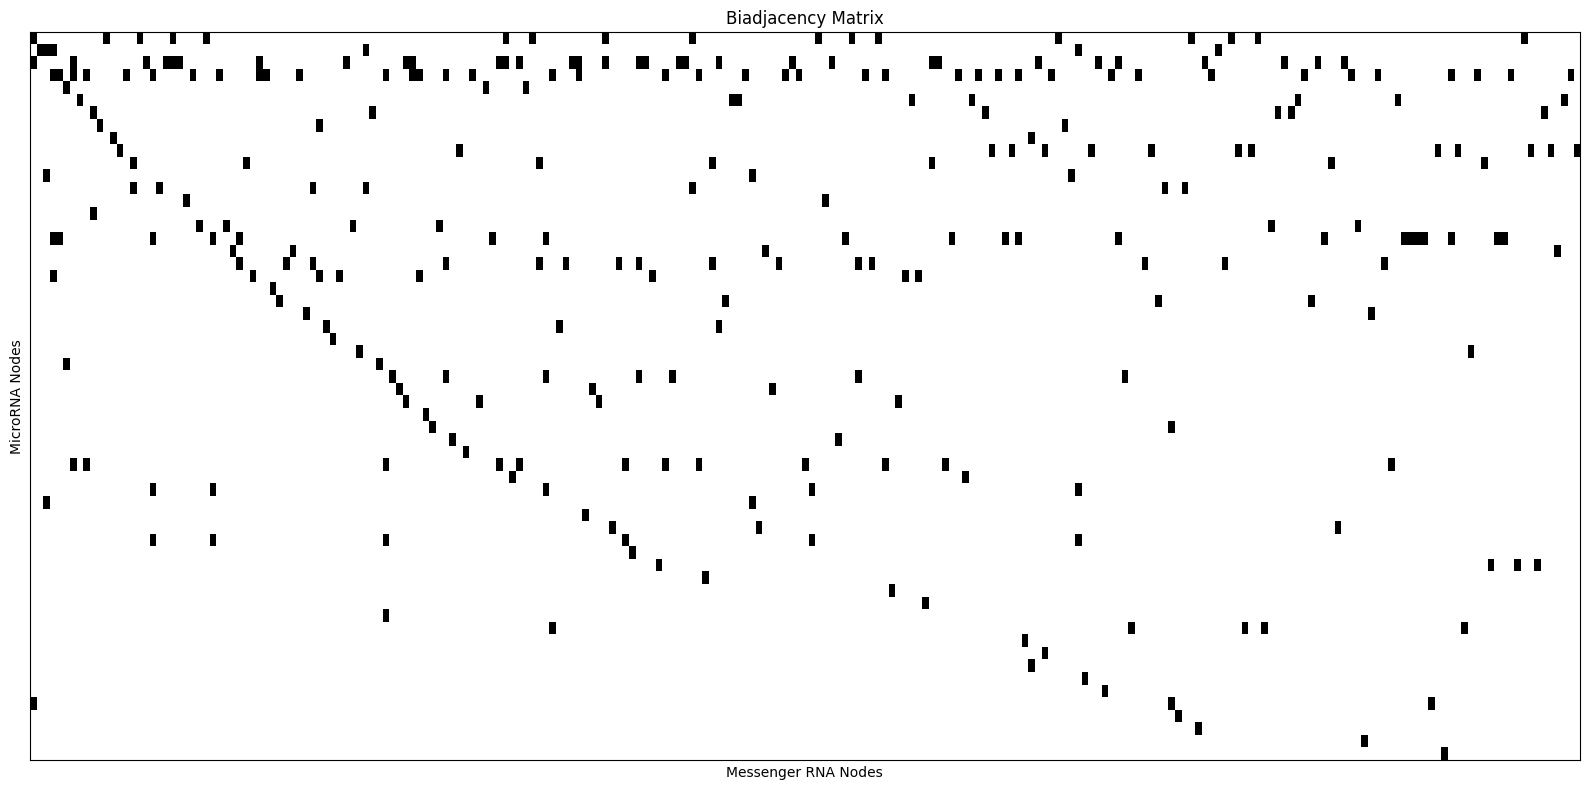

In [20]:
# Print the global network analysis report
global_report(edges_df, nodes_df)

In [21]:
# Print the analysis report for the microRNA nodes
partition_report(nodes_df, 'MicroRNA')

===== MicroRNAs =====

> number of nodes = 58
> number of nodes in the largest component = 22 (37.93%)

##### Betweenness Centrality #####

> descriptive statistics: 
       betweenness_centrality
count               22.000000
mean                 0.098179
std                  0.138186
min                  0.000000
25%                  0.020574
50%                  0.047024
75%                  0.106675
max                  0.497522

> top-5 nodes in descending order: 
             label  betweenness_centrality
0    hsa-miR-96-5p                0.497522
1  hsa-miR-106b-5p                0.491275
2  hsa-miR-106a-5p                0.182827
3   hsa-miR-182-5p                0.156133
4  hsa-miR-200b-3p                0.152077

> bottom-5 nodes in descending order: 
              label  betweenness_centrality
17   hsa-miR-19a-3p                0.017603
18   hsa-miR-27a-3p                0.011782
19    hsa-miR-17-5p                0.011150
20   hsa-miR-19b-3p                0.005821
21  hsa-

### Luminal A

In [22]:
# Perform the topological analysis of the bipartite network
edges_df, nodes_df = bipartite_topological_analysis('Luminal A')

In [23]:
# Print the list of edges of the network
edges_df

,source,target,mirtarbase,correlation,qvalue
0,hsa-miR-200a-3p,WWTR1,NaN,-0.477,0.0
1,hsa-miR-141-3p,PHYHIPL,NaN,-0.452,0.0
2,hsa-miR-96-5p,SGMS2,NaN,-0.438,0.0
3,hsa-miR-29b-3p,PCSK5,NaN,-0.425,0.0
4,hsa-miR-342-3p,FRMD4A,NaN,-0.425,0.0
...,...,...,...,...,...
254,hsa-miR-106b-5p,CYP2U1,NaN,-0.300,0.0
255,hsa-miR-17-5p,SAR1B,NaN,-0.300,0.0
256,hsa-miR-200b-3p,SLC24A4,NaN,-0.300,0.0
257,hsa-miR-96-5p,SH3PXD2B,NaN,-0.300,0.0


In [24]:
# Print the attributes of the network nodes
nodes_df

,id,label,type,connected_component_id,is_in_largest_component,betweenness_centrality,closeness_centrality,degree_centrality,redundancy_coefficient
0,hsa-miR-200a-3p,hsa-miR-200a-3p,MicroRNA,0,1,0.145679,0.245753,0.079096,0.142857
1,hsa-miR-141-3p,hsa-miR-141-3p,MicroRNA,0,1,0.232485,0.231097,0.090395,0.091667
2,hsa-miR-96-5p,hsa-miR-96-5p,MicroRNA,0,1,0.564774,0.309558,0.214689,0.008535
3,hsa-miR-29b-3p,hsa-miR-29b-3p,MicroRNA,0,1,0.242159,0.253209,0.152542,0.019943
4,hsa-miR-342-3p,hsa-miR-342-3p,MicroRNA,0,1,0.118532,0.169399,0.073446,0.000000
...,...,...,...,...,...,...,...,...,...
246,LUZP1,LUZP1,Messenger RNA,0,1,0.000000,0.217239,0.047619,NaN
247,CYBRD1,CYBRD1,Messenger RNA,0,1,0.000000,0.265103,0.047619,NaN
248,TBX15,TBX15,Messenger RNA,0,1,0.000000,0.252539,0.047619,NaN
249,SLC24A4,SLC24A4,Messenger RNA,0,1,0.000000,0.371884,0.047619,NaN


> number of edges = 259

> number of nodes (251):
- MicroRNAs = 44 (17.53%)
- Messenger RNAs = 207 (82.47%)

> network density = 0.03

> number of connected components = 22
> number of nodes in the largest component = 198 (78.88%)


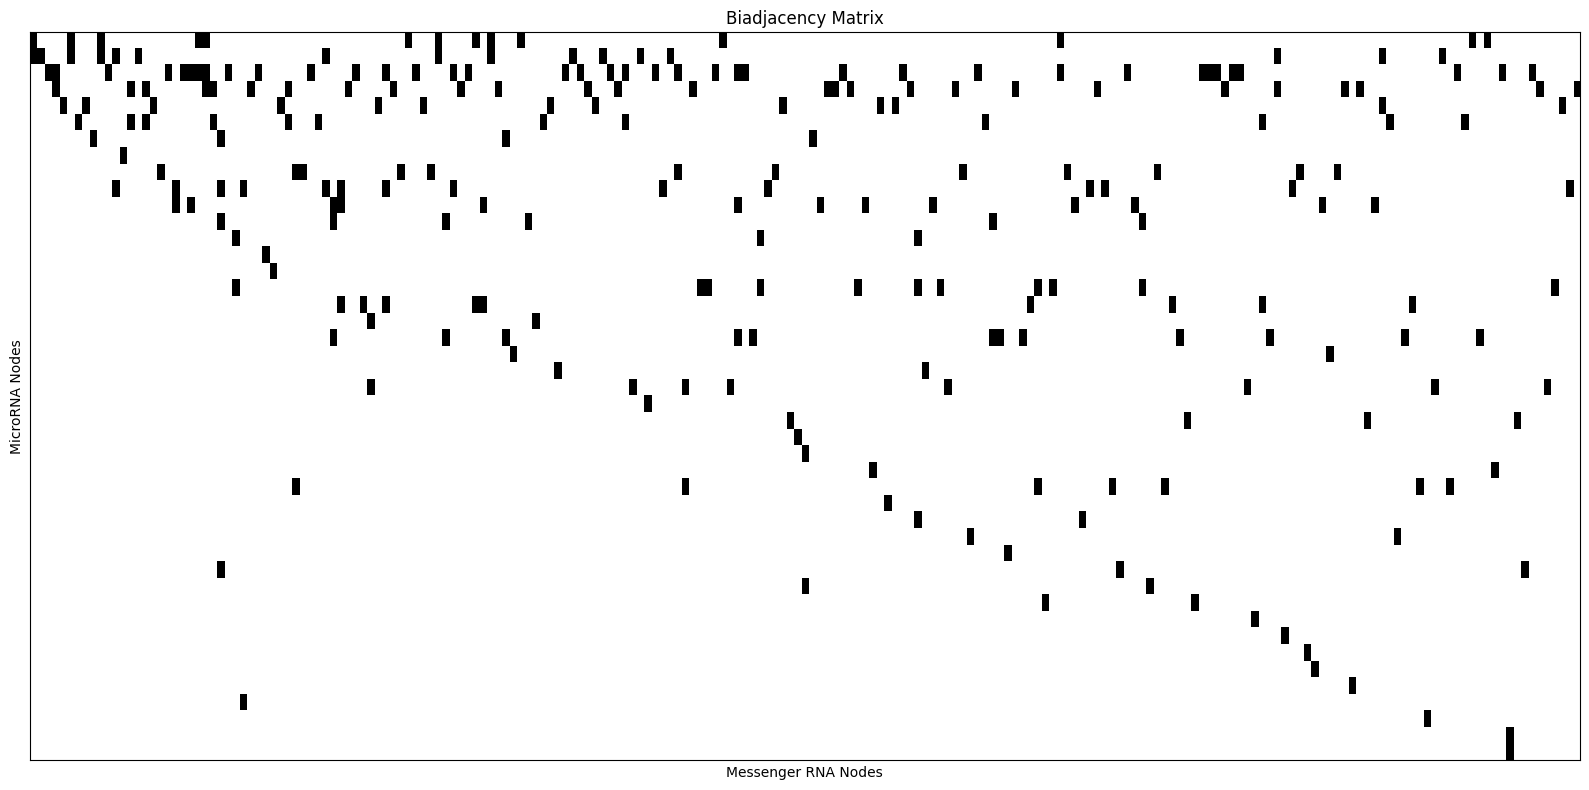

In [25]:
# Print the global network analysis report
global_report(edges_df, nodes_df)

In [26]:
# Print the analysis report for the microRNA nodes
partition_report(nodes_df, 'MicroRNA')

===== MicroRNAs =====

> number of nodes = 44
> number of nodes in the largest component = 21 (47.73%)

##### Betweenness Centrality #####

> descriptive statistics: 
       betweenness_centrality
count               21.000000
mean                 0.131272
std                  0.128082
min                  0.000000
25%                  0.024279
50%                  0.115648
75%                  0.164148
max                  0.564774

> top-5 nodes in descending order: 
             label  betweenness_centrality
0    hsa-miR-96-5p                0.564774
1   hsa-miR-29b-3p                0.242159
2  hsa-miR-200b-3p                0.234775
3   hsa-miR-141-3p                0.232485
4  hsa-miR-301a-3p                0.222737

> bottom-5 nodes in descending order: 
              label  betweenness_centrality
16  hsa-miR-148b-3p                0.020274
17   hsa-miR-192-5p                0.010163
18   hsa-miR-92a-3p                0.010163
19   hsa-miR-20a-5p                0.000181
20  hsa-

### Luminal B

In [27]:
# Perform the topological analysis of the bipartite network
edges_df, nodes_df = bipartite_topological_analysis('Luminal B')

In [28]:
# Print the list of edges of the network
edges_df

,source,target,mirtarbase,correlation,qvalue
0,hsa-miR-200c-3p,ZMAT3,MIRT209182,-0.493,0.000
1,hsa-let-7g-5p,KLHL13,NaN,-0.467,0.001
2,hsa-miR-30d-5p,FST,NaN,-0.461,0.001
3,hsa-miR-200c-3p,FAM126A,NaN,-0.458,0.001
4,hsa-miR-151a-3p,FRK,MIRT508167,-0.456,0.001
...,...,...,...,...,...
579,hsa-miR-339-5p,DAAM2,NaN,-0.300,0.030
580,hsa-miR-30b-5p,TMTC3,NaN,-0.300,0.030
581,hsa-miR-205-5p,RAB11FIP1,MIRT505979,-0.300,0.030
582,hsa-miR-222-3p,PANK3,MIRT046819,-0.300,0.030


In [29]:
# Print the attributes of the network nodes
nodes_df

,id,label,type,connected_component_id,is_in_largest_component,betweenness_centrality,closeness_centrality,degree_centrality,redundancy_coefficient
0,hsa-miR-200c-3p,hsa-miR-200c-3p,MicroRNA,0,1,0.251333,0.259843,0.080402,0.004032
1,hsa-let-7g-5p,hsa-let-7g-5p,MicroRNA,0,1,0.047021,0.131671,0.027638,0.000000
2,hsa-miR-30d-5p,hsa-miR-30d-5p,MicroRNA,0,1,0.025793,0.180205,0.017588,0.000000
3,hsa-miR-151a-3p,hsa-miR-151a-3p,MicroRNA,0,1,0.012929,0.193690,0.007538,0.000000
4,hsa-miR-27b-3p,hsa-miR-27b-3p,MicroRNA,0,1,0.196048,0.248588,0.080402,0.018145
...,...,...,...,...,...,...,...,...,...
554,AFF2,AFF2,Messenger RNA,0,1,0.000000,0.192308,0.015152,NaN
555,DAAM2,DAAM2,Messenger RNA,9,0,NaN,NaN,NaN,NaN
556,RAB11FIP1,RAB11FIP1,Messenger RNA,1,0,NaN,NaN,NaN,NaN
557,PANK3,PANK3,Messenger RNA,0,1,0.000000,0.267746,0.015152,NaN


> number of edges = 584

> number of nodes (559):
- MicroRNAs = 105 (18.78%)
- Messenger RNAs = 454 (81.22%)

> network density = 0.01

> number of connected components = 38
> number of nodes in the largest component = 464 (83.01%)


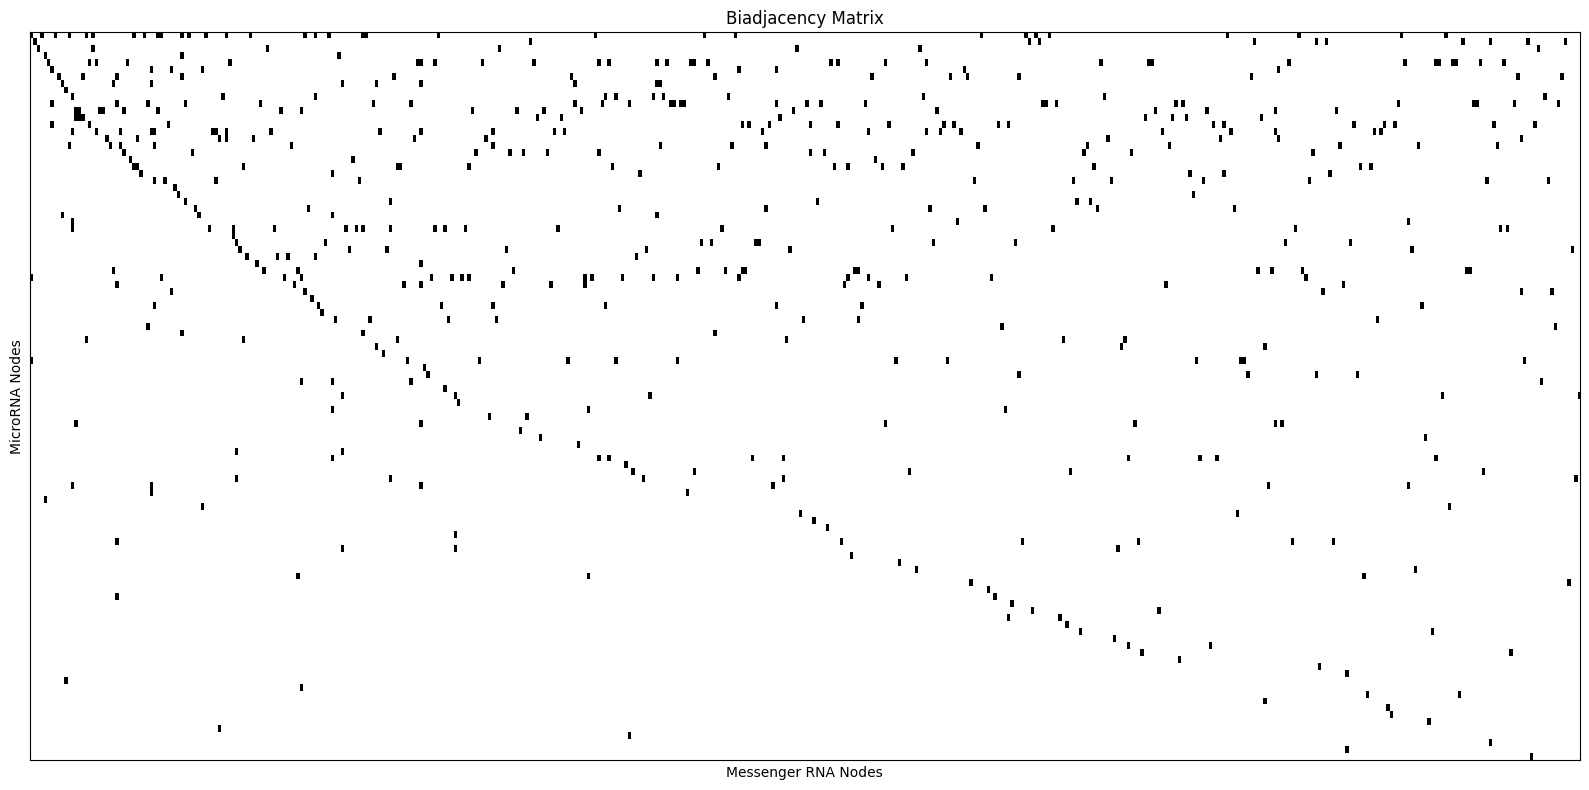

In [30]:
# Print the global network analysis report
global_report(edges_df, nodes_df)

In [31]:
# Print the analysis report for the microRNA nodes
partition_report(nodes_df, 'MicroRNA')

===== MicroRNAs =====

> number of nodes = 105
> number of nodes in the largest component = 66 (62.86%)

##### Betweenness Centrality #####

> descriptive statistics: 
       betweenness_centrality
count               66.000000
mean                 0.045449
std                  0.057569
min                  0.000000
25%                  0.006429
50%                  0.024577
75%                  0.050019
max                  0.251333

> top-5 nodes in descending order: 
             label  betweenness_centrality
0  hsa-miR-200c-3p                0.251333
1  hsa-miR-106b-5p                0.234669
2   hsa-miR-27b-3p                0.196048
3   hsa-miR-18a-5p                0.174641
4   hsa-miR-33a-5p                0.167084

> bottom-5 nodes in descending order: 
              label  betweenness_centrality
61   hsa-miR-212-3p                     0.0
62  hsa-miR-148b-3p                     0.0
63   hsa-miR-150-5p                     0.0
64      hsa-miR-421                     0.0
65    h

### Normal

In [32]:
# Perform the topological analysis of the bipartite network
edges_df, nodes_df = bipartite_topological_analysis('Normal')

In [33]:
# Print the list of edges of the network
edges_df

,source,target,mirtarbase,correlation,qvalue
0,hsa-miR-22-3p,RPS3,NaN,-0.816,0.00
1,hsa-miR-452-5p,RPA1,NaN,-0.810,0.00
2,hsa-miR-141-3p,TRHDE,NaN,-0.807,0.00
3,hsa-miR-22-3p,RPL14,NaN,-0.804,0.00
4,hsa-miR-22-3p,LRRC1,MIRT030660,-0.800,0.00
...,...,...,...,...,...
5067,hsa-miR-93-5p,CREBRF,MIRT028082,-0.332,0.05
5068,hsa-miR-93-5p,USP37,NaN,-0.332,0.05
5069,hsa-miR-139-5p,ZC3H12A,NaN,-0.332,0.05
5070,hsa-miR-326,FAM168A,NaN,-0.332,0.05


In [34]:
# Print the attributes of the network nodes
nodes_df

,id,label,type,connected_component_id,is_in_largest_component,betweenness_centrality,closeness_centrality,degree_centrality,redundancy_coefficient
0,hsa-miR-22-3p,hsa-miR-22-3p,MicroRNA,0,1,0.066533,0.284036,0.052922,0.066239
1,hsa-miR-452-5p,hsa-miR-452-5p,MicroRNA,0,1,0.025160,0.273056,0.024256,0.074592
2,hsa-miR-141-3p,hsa-miR-141-3p,MicroRNA,0,1,0.015155,0.160244,0.012495,0.376114
3,hsa-miR-200a-3p,hsa-miR-200a-3p,MicroRNA,0,1,0.012283,0.160176,0.010290,0.539683
4,hsa-miR-224-5p,hsa-miR-224-5p,MicroRNA,0,1,0.033811,0.271194,0.027563,0.043243
...,...,...,...,...,...,...,...,...,...
2910,NKAPD1,NKAPD1,Messenger RNA,0,1,0.000000,0.355499,0.006579,NaN
2911,SLITRK4,SLITRK4,Messenger RNA,1,0,NaN,NaN,NaN,NaN
2912,PHF21A,PHF21A,Messenger RNA,0,1,0.000000,0.430022,0.006579,NaN
2913,ZC3H12A,ZC3H12A,Messenger RNA,0,1,0.000000,0.416195,0.006579,NaN


> number of edges = 5072

> number of nodes (2915):
- MicroRNAs = 166 (5.69%)
- Messenger RNAs = 2749 (94.31%)

> network density = 0.01

> number of connected components = 14
> number of nodes in the largest component = 2873 (98.56%)


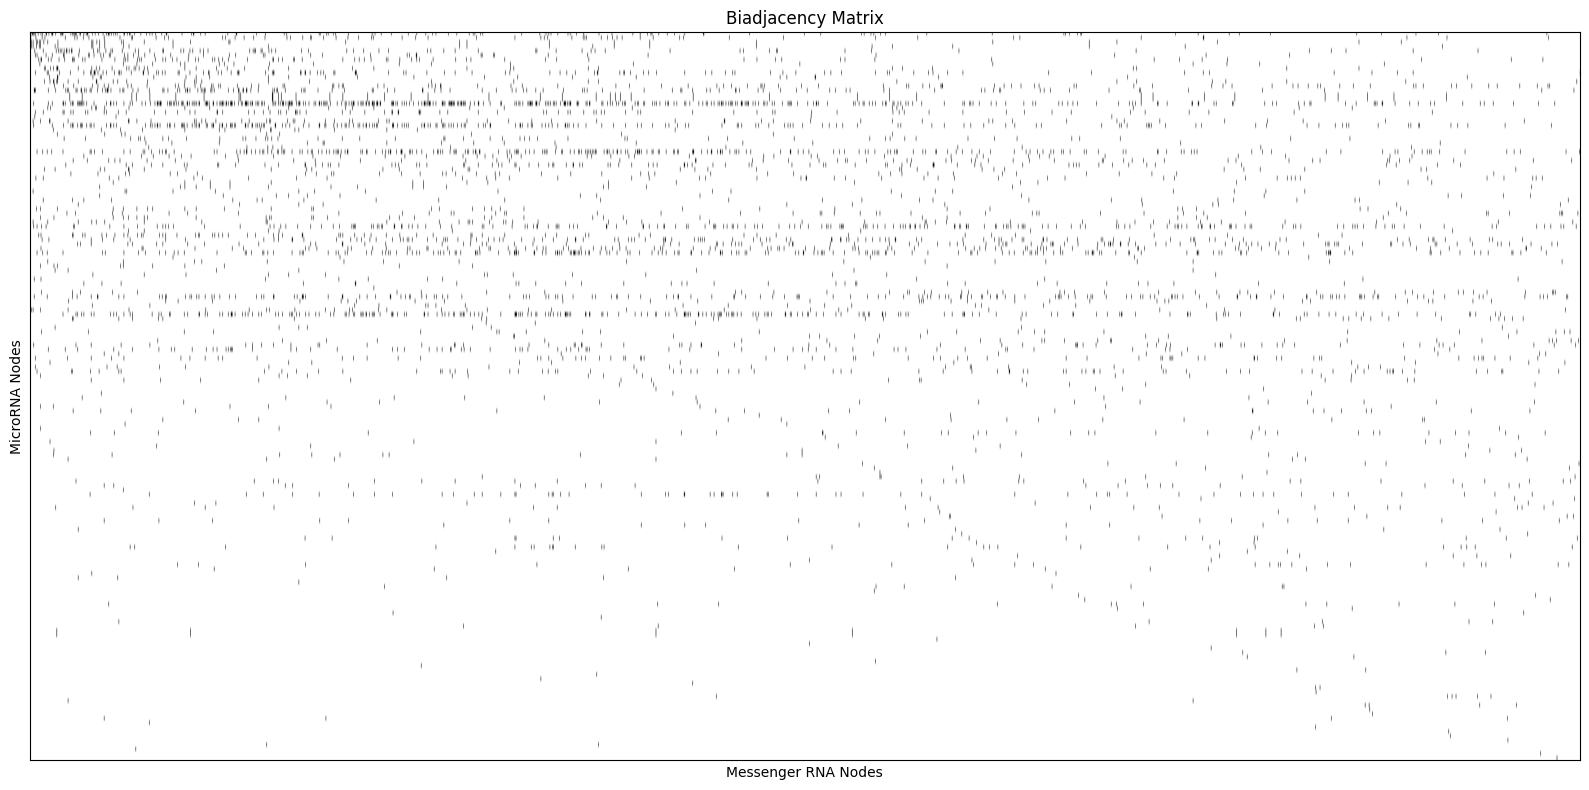

In [35]:
# Print the global network analysis report
global_report(edges_df, nodes_df)

In [36]:
# Print the analysis report for the microRNA nodes
partition_report(nodes_df, 'MicroRNA')

===== MicroRNAs =====

> number of nodes = 166
> number of nodes in the largest component = 152 (91.57%)

##### Betweenness Centrality #####

> descriptive statistics: 
       betweenness_centrality
count              152.000000
mean                 0.016821
std                  0.032937
min                  0.000000
25%                  0.001429
50%                  0.004789
75%                  0.015310
max                  0.222570

> top-5 nodes in descending order: 
            label  betweenness_centrality
0   hsa-let-7d-5p                0.222570
1  hsa-miR-20b-5p                0.182494
2  hsa-miR-30e-5p                0.172102
3  hsa-miR-15a-5p                0.113808
4   hsa-miR-24-3p                0.096287

> bottom-5 nodes in descending order: 
               label  betweenness_centrality
147  hsa-miR-551b-3p                     0.0
148   hsa-miR-29a-3p                     0.0
149   hsa-miR-187-3p                     0.0
150   hsa-miR-100-5p                     0.0
151   h

# Tripartite Networks

## Functions

### Creation of Network Object

In [37]:
def create_tripartite_network(edges_df, nodes_df):
    # Create the microRNA-mRNA-pathway network object
    T = nx.from_pandas_edgelist(
        df=edges_df,
        source='source',
        target='target',
        edge_attr=True,
        create_using=nx.DiGraph(),
    )

    # Assign partition attribute
    attr_dict = nodes_df.set_index('id')['type'].to_dict()
    nx.set_node_attributes(
        G=T, values=attr_dict, name='partition'
    )

    # Assign pathway q-values
    attr_dict = (
        nodes_df
        .set_index('id')['qvalue']
        .dropna()
        .to_dict()
    )
    nx.set_node_attributes(
        G=T, values=attr_dict, name='qvalue'
    )

    return T

### Topological Analysis

#### Identify Paths Between MicroRNAs and Pathways

In [38]:
def identify_mir_to_pathway_paths(T, mir_set):
    # Create a dictionary to store the paths
    paths = dict()

    # Iterate over the microRNAs
    for mir in mir_set:
        # Initialize the microRNA path list
        paths[mir] = list()

        # Iterate over the neighbors of microRNAs
        for gene in T.neighbors(mir):
            # Iterate over the neighbors of the neighbors of microRNAs
            for pathway in T.neighbors(gene):
                # Store the other two nodes in the path
                paths[mir].append((gene, pathway))

    # Add the paths as an attribute of the microRNA nodes
    nx.set_node_attributes(
        G=T, values=paths, name='paths'
    )

    return paths

#### Pathway Reach Calculation

In [39]:
def compute_pathway_reach(T, paths, pathway_set):
    # Create a list to store the metric values
    pathway_reach = dict()

    # Compute the number of pathway nodes in the network
    total_pathways = len(pathway_set)

    # Iterate over the microRNAs
    for mir in paths.keys():
        # Check if the microRNA reaches any pathway
        if len(paths[mir]) == 0:
            pathway_reach[mir] = 0
        else:
            # Create a list to store the reached pathways
            reached_pathways = list()

            # Iterate over the paths
            for _, pathway in paths[mir]:
                reached_pathways.append(pathway)

            # Remove the repeated patways
            reached_pathways = set(reached_pathways)

            # Store the pathway reach value in the dictionary
            value = len(reached_pathways) / total_pathways
            pathway_reach[mir] = value

    # Add the pathway reach as an attribute of the nodes
    nx.set_node_attributes(
        G=T, values=pathway_reach, name='pathway_reach'
    )

#### Functional Impact Calculation

In [40]:
def compute_functional_impact(T, paths):
    # Create a list to store the metric values
    functional_impact = dict()

    # Iterate over the microRNAs
    for mir in paths.keys():
        # Initialize the metric value
        functional_impact[mir] = 0.0

        # Check if the microRNA reaches any pathway
        if len(paths[mir]) > 0:
            # Iterate over the paths
            for gene, pathway in paths[mir]:
                # Interaction correlation
                w1 = abs(T[mir][gene]['correlation'])

                # Interaction confidence
                w2 = 1 - (T[mir][gene]['qvalue'])

                # Membership relevance
                w3 = 1 - T.nodes[pathway]['qvalue']
                
                # Store the pathway reach value in the dictionary
                impact = w1 * w2 * w3
                functional_impact[mir] += impact
            
            # Normalize the metric value for comparisons
            functional_impact[mir] /= len(paths[mir])
    
    # Add the functional impact as an attribute of the nodes
    nx.set_node_attributes(
        G=T, values=functional_impact, name='functional_impact'
    )

#### Compute the Set of Metrics

In [41]:
def compute_tripartite_metrics(T):
    # Define the nodes in the microRNA and pathway partitions
    mir_set = [
        n for n, d in T.nodes(data=True) 
        if d['partition'] == 'MicroRNA'
    ]
    pathway_set = [
        n for n, d in T.nodes(data=True) 
        if d['partition'] == 'Pathway'
    ]

    # Detect the paths between microRNAs and pathways
    paths = identify_mir_to_pathway_paths(T, mir_set)

    # Compute the pathway reach of microRNAs
    compute_pathway_reach(T, paths, pathway_set)

    # Compute the functional impact of microRNAs
    compute_functional_impact(T, paths)

    # Store the node attributes in a DataFrame
    nodes = dict(T.nodes(data=True))
    metrics_df = (
        pd.DataFrame.from_dict(data=nodes, orient='index')
        .reset_index()
        .rename(columns={'index': 'id'})
        [['id', 'pathway_reach', 'functional_impact']]
    )

    return metrics_df

### Analysis Report

#### Print the Description of the Metric Values

In [42]:
def print_metric_values_description(metrics_df, metric, nodes_to_rank=5):
    # Print the name of the metric as a title
    metric_name = metric.replace('_', ' ')
    print(f'\n##### {metric_name.title()} #####\n')

    # Sort the nodes according to the parameters
    sorted_df = (
        metrics_df
        .sort_values(by=metric, ascending=False)
        .dropna(subset=metric)
        .reset_index(drop=True)
        [['label', metric]]
    )
    
    # Print the descriptive statistics
    print(f'> descriptive statistics: \n{sorted_df.describe()}')
    
    # Print the top and bottom ranked nodes
    for rank in ['top', 'bottom']:
        if rank == 'top':
            nodes_df = sorted_df.head(nodes_to_rank)
        else:
            nodes_df = sorted_df.tail(nodes_to_rank)

        print(
            f'\n> {rank}-{nodes_to_rank} nodes in '
            + f'descending order: \n{nodes_df}'
        )

#### MicroRNA Partition Report

In [43]:
def mir_partition_report(nodes_df):
    if nodes_df.empty:
        print('No tripartite network available.')
        return

    # Select the partition nodes
    partition = 'MicroRNA'
    partition_df = nodes_df.query('type == @partition')
    print(f'===== {partition}s =====')

    # Print the description of the metric values
    for metric in METRICS['tripartite']:
        print_metric_values_description(
            metrics_df=partition_df,
            metric=metric,
        )

### Controller

In [44]:
def tripartite_topological_analysis(group):
    # Define the group directory name
    group_dir = group.lower().replace(' ', '-')

    # Define input and output directories
    input_dir_path = NETWORK_DATA_DIRS['processed'][group_dir]
    output_dir_path = os.path.join(
        '..',
        'data',
        'processed',
        'network-analysis',
        group_dir,
    )

    edges_file = 'tripartite-network-edges.csv'
    nodes_file = 'tripartite-network-nodes.csv'
    
    # Create DataFrames to represent the network
    edges_df = pd.read_csv(os.path.join(input_dir_path, edges_file))
    nodes_df = pd.read_csv(os.path.join(input_dir_path, nodes_file))

    # Check whether the tripartite network exists
    if edges_df.empty or nodes_df.empty:
        edges_df.to_csv(
            os.path.join(output_dir_path, edges_file),
            index=False,
        )
        nodes_df.to_csv(
            os.path.join(output_dir_path, nodes_file),
            index=False,
        )

        return edges_df, nodes_df

    # Create the network object
    T = create_tripartite_network(edges_df, nodes_df)

    # Perform the topological analysis of the network
    metrics_df = compute_tripartite_metrics(T)

    # Add tripartite metrics as node attributes
    nodes_df = pd.merge(
        left=nodes_df,
        right=metrics_df,
        how='left',
        on='id',
    )

    # Store the DataFrame of nodes with metric values
    edges_df.to_csv(
        os.path.join(output_dir_path, edges_file),
        index=False,
    )
    nodes_df.to_csv(
        os.path.join(output_dir_path, nodes_file),
        index=False,
    )

    return edges_df, nodes_df

## Analyze the Network by Group

### Basal-like

In [45]:
# Perform the topological analysis of the tripartite network
edges_df, nodes_df = tripartite_topological_analysis('Basal-like')

In [46]:
# Print the list of edges of the network
edges_df

,source,target,mirtarbase,correlation,qvalue
0,hsa-miR-182-5p,RAB27A,NaN,-0.564,0.000
1,hsa-miR-18a-5p,ORAI3,MIRT050737,-0.545,0.000
2,hsa-miR-18a-5p,ZBTB4,NaN,-0.532,0.001
3,hsa-miR-96-5p,RAB27A,NaN,-0.496,0.004
4,hsa-miR-106b-5p,ATXN1,MIRT441140,-0.495,0.004
...,...,...,...,...,...
383,ESR1,KEGG:05205,NaN,NaN,NaN
384,TLR4,KEGG:05205,NaN,NaN,NaN
385,IGF1R,KEGG:05205,NaN,NaN,NaN
386,PRKACB,KEGG:05205,NaN,NaN,NaN


In [47]:
# Print the attributes of the network nodes
nodes_df

,id,label,type,qvalue,pathway_reach,functional_impact
0,hsa-miR-182-5p,hsa-miR-182-5p,MicroRNA,NaN,0.555556,0.365727
1,hsa-miR-18a-5p,hsa-miR-18a-5p,MicroRNA,NaN,0.666667,0.366496
2,hsa-miR-96-5p,hsa-miR-96-5p,MicroRNA,NaN,0.666667,0.402333
3,hsa-miR-106b-5p,hsa-miR-106b-5p,MicroRNA,NaN,0.777778,0.375430
4,hsa-miR-221-3p,hsa-miR-221-3p,MicroRNA,NaN,0.444444,0.468612
...,...,...,...,...,...,...
295,KEGG:01521,EGFR tyrosine kinase inhibitor resistance,Pathway,0.025434,NaN,NaN
296,KEGG:01522,Endocrine resistance,Pathway,0.042191,NaN,NaN
297,KEGG:04010,MAPK signaling pathway,Pathway,0.042191,NaN,NaN
298,KEGG:04068,FoxO signaling pathway,Pathway,0.042191,NaN,NaN


In [48]:
# Print the analysis report for the microRNA nodes
mir_partition_report(nodes_df)

===== MicroRNAs =====

##### Pathway Reach #####

> descriptive statistics: 
       pathway_reach
count      58.000000
mean        0.214559
std         0.292763
min         0.000000
25%         0.000000
50%         0.000000
75%         0.416667
max         0.888889

> top-5 nodes in descending order: 
             label  pathway_reach
0   hsa-miR-128-3p       0.888889
1    hsa-let-7c-5p       0.888889
2   hsa-miR-27a-3p       0.888889
3  hsa-miR-106b-5p       0.777778
4   hsa-miR-15b-5p       0.666667

> bottom-5 nodes in descending order: 
              label  pathway_reach
53    hsa-miR-22-3p            0.0
54  hsa-miR-125b-5p            0.0
55   hsa-miR-19a-3p            0.0
56   hsa-miR-29a-3p            0.0
57     hsa-miR-378c            0.0

##### Functional Impact #####

> descriptive statistics: 
       functional_impact
count          58.000000
mean            0.176628
std             0.192121
min             0.000000
25%             0.000000
50%             0.000000
75%      

### Luminal A

In [49]:
# Perform the topological analysis of the tripartite network
edges_df, nodes_df = tripartite_topological_analysis('Luminal A')

In [50]:
# Print the list of edges of the network
edges_df

,source,target,mirtarbase,correlation,qvalue
0,hsa-miR-200a-3p,WWTR1,NaN,-0.477,0.0
1,hsa-miR-141-3p,PHYHIPL,NaN,-0.452,0.0
2,hsa-miR-96-5p,SGMS2,NaN,-0.438,0.0
3,hsa-miR-29b-3p,PCSK5,NaN,-0.425,0.0
4,hsa-miR-342-3p,FRMD4A,NaN,-0.425,0.0
...,...,...,...,...,...
321,ITGA9,KEGG:05165,NaN,NaN,NaN
322,PPP2CB,KEGG:05165,NaN,NaN,NaN
323,HEY2,KEGG:05165,NaN,NaN,NaN
324,CDK6,KEGG:05165,NaN,NaN,NaN


In [51]:
# Print the attributes of the network nodes
nodes_df

,id,label,type,qvalue,pathway_reach,functional_impact
0,hsa-miR-200a-3p,hsa-miR-200a-3p,MicroRNA,NaN,0.428571,0.356319
1,hsa-miR-141-3p,hsa-miR-141-3p,MicroRNA,NaN,0.428571,0.334756
2,hsa-miR-96-5p,hsa-miR-96-5p,MicroRNA,NaN,1.000000,0.330498
3,hsa-miR-29b-3p,hsa-miR-29b-3p,MicroRNA,NaN,0.714286,0.342577
4,hsa-miR-342-3p,hsa-miR-342-3p,MicroRNA,NaN,0.714286,0.351736
...,...,...,...,...,...,...
253,KEGG:04518,Integrin signaling,Pathway,0.018969,NaN,NaN
254,KEGG:04820,Cytoskeleton in muscle cells,Pathway,0.018969,NaN,NaN
255,KEGG:05202,Transcriptional misregulation in cancer,Pathway,0.018969,NaN,NaN
256,KEGG:04151,PI3K-Akt signaling pathway,Pathway,0.024587,NaN,NaN


In [52]:
# Print the analysis report for the microRNA nodes
mir_partition_report(nodes_df)

===== MicroRNAs =====

##### Pathway Reach #####

> descriptive statistics: 
       pathway_reach
count      44.000000
mean        0.168831
std         0.260102
min         0.000000
25%         0.000000
50%         0.000000
75%         0.285714
max         1.000000

> top-5 nodes in descending order: 
            label  pathway_reach
0   hsa-miR-96-5p       1.000000
1  hsa-miR-29b-3p       0.714286
2  hsa-miR-342-3p       0.714286
3  hsa-miR-29c-3p       0.714286
4  hsa-miR-324-5p       0.714286

> bottom-5 nodes in descending order: 
              label  pathway_reach
39   hsa-miR-20b-5p            0.0
40   hsa-miR-744-5p            0.0
41   hsa-miR-20a-5p            0.0
42   hsa-miR-210-3p            0.0
43  hsa-miR-365a-3p            0.0

##### Functional Impact #####

> descriptive statistics: 
       functional_impact
count          44.000000
mean            0.134699
std             0.164352
min             0.000000
25%             0.000000
50%             0.000000
75%            

### Luminal B

In [53]:
# Perform the topological analysis of the tripartite network
edges_df, nodes_df = tripartite_topological_analysis('Luminal B')

In [54]:
# Print the list of edges of the network
edges_df

,source,target,mirtarbase,correlation,qvalue
0,hsa-miR-200c-3p,ZMAT3,MIRT209182,-0.493,0.000
1,hsa-let-7g-5p,KLHL13,NaN,-0.467,0.001
2,hsa-miR-30d-5p,FST,NaN,-0.461,0.001
3,hsa-miR-200c-3p,FAM126A,NaN,-0.458,0.001
4,hsa-miR-151a-3p,FRK,MIRT508167,-0.456,0.001
...,...,...,...,...,...
961,SOS1,KEGG:04630,NaN,NaN,NaN
962,CCND2,KEGG:04630,NaN,NaN,NaN
963,JAK1,KEGG:04630,NaN,NaN,NaN
964,IL6ST,KEGG:04630,NaN,NaN,NaN


In [55]:
# Print the attributes of the network nodes
nodes_df

,id,label,type,qvalue,pathway_reach,functional_impact
0,hsa-miR-200c-3p,hsa-miR-200c-3p,MicroRNA,NaN,0.645161,0.321455
1,hsa-let-7g-5p,hsa-let-7g-5p,MicroRNA,NaN,0.096774,0.331025
2,hsa-miR-30d-5p,hsa-miR-30d-5p,MicroRNA,NaN,0.129032,0.345592
3,hsa-miR-151a-3p,hsa-miR-151a-3p,MicroRNA,NaN,0.000000,0.000000
4,hsa-miR-27b-3p,hsa-miR-27b-3p,MicroRNA,NaN,0.677419,0.315761
...,...,...,...,...,...,...
585,KEGG:04926,Relaxin signaling pathway,Pathway,0.038553,NaN,NaN
586,KEGG:04012,ErbB signaling pathway,Pathway,0.038965,NaN,NaN
587,KEGG:04068,FoxO signaling pathway,Pathway,0.041710,NaN,NaN
588,KEGG:04720,Long-term potentiation,Pathway,0.045329,NaN,NaN


In [56]:
# Print the analysis report for the microRNA nodes
mir_partition_report(nodes_df)

===== MicroRNAs =====

##### Pathway Reach #####

> descriptive statistics: 
       pathway_reach
count     105.000000
mean        0.116129
std         0.184421
min         0.000000
25%         0.000000
50%         0.032258
75%         0.129032
max         0.903226

> top-5 nodes in descending order: 
             label  pathway_reach
0   hsa-miR-15b-5p       0.903226
1   hsa-miR-27b-3p       0.677419
2  hsa-miR-200c-3p       0.645161
3   hsa-miR-27a-3p       0.645161
4  hsa-miR-106b-5p       0.612903

> bottom-5 nodes in descending order: 
               label  pathway_reach
100     hsa-miR-378c            0.0
101     hsa-miR-320b            0.0
102   hsa-miR-501-3p            0.0
103   hsa-miR-454-3p            0.0
104  hsa-miR-146b-5p            0.0

##### Functional Impact #####

> descriptive statistics: 
       functional_impact
count         105.000000
mean            0.174767
std             0.165304
min             0.000000
25%             0.000000
50%             0.297235
75%

### Normal

In [57]:
# Perform the topological analysis of the tripartite network
edges_df, nodes_df = tripartite_topological_analysis('Normal')

In [58]:
# Print the list of edges of the network
edges_df

,source,target,mirtarbase,correlation,qvalue
0,hsa-miR-22-3p,RPS3,NaN,-0.816,0.0
1,hsa-miR-452-5p,RPA1,NaN,-0.810,0.0
2,hsa-miR-141-3p,TRHDE,NaN,-0.807,0.0
3,hsa-miR-22-3p,RPL14,NaN,-0.804,0.0
4,hsa-miR-22-3p,LRRC1,MIRT030660,-0.800,0.0
...,...,...,...,...,...
8829,FAS,KEGG:04668,NaN,NaN,NaN
8830,CASP10,KEGG:04668,NaN,NaN,NaN
8831,LIF,KEGG:04668,NaN,NaN,NaN
8832,CSF1,KEGG:04668,NaN,NaN,NaN


In [59]:
# Print the attributes of the network nodes
nodes_df

,id,label,type,qvalue,pathway_reach,functional_impact
0,hsa-miR-22-3p,hsa-miR-22-3p,MicroRNA,NaN,0.855856,0.519499
1,hsa-miR-452-5p,hsa-miR-452-5p,MicroRNA,NaN,0.513514,0.505536
2,hsa-miR-141-3p,hsa-miR-141-3p,MicroRNA,NaN,0.468468,0.709255
3,hsa-miR-200a-3p,hsa-miR-200a-3p,MicroRNA,NaN,0.459459,0.676958
4,hsa-miR-224-5p,hsa-miR-224-5p,MicroRNA,NaN,0.540541,0.548280
...,...,...,...,...,...,...
3021,KEGG:04664,Fc epsilon RI signaling pathway,Pathway,0.046322,NaN,NaN
3022,KEGG:05217,Basal cell carcinoma,Pathway,0.047513,NaN,NaN
3023,KEGG:05130,Pathogenic Escherichia coli infection,Pathway,0.047713,NaN,NaN
3024,KEGG:05235,PD-L1 expression and PD-1 checkpoint pathway i...,Pathway,0.048613,NaN,NaN


In [60]:
# Print the analysis report for the microRNA nodes
mir_partition_report(nodes_df)

===== MicroRNAs =====

##### Pathway Reach #####

> descriptive statistics: 
       pathway_reach
count     166.000000
mean        0.233909
std         0.266131
min         0.000000
25%         0.018018
50%         0.108108
75%         0.396396
max         0.990991

> top-5 nodes in descending order: 
            label  pathway_reach
0  hsa-miR-20b-5p       0.990991
1     hsa-miR-107       0.945946
2  hsa-miR-15a-5p       0.927928
3   hsa-let-7d-5p       0.900901
4    hsa-miR-7-5p       0.882883

> bottom-5 nodes in descending order: 
               label  pathway_reach
161    hsa-let-7i-5p            0.0
162   hsa-miR-503-5p            0.0
163   hsa-miR-187-3p            0.0
164  hsa-miR-199a-5p            0.0
165   hsa-miR-100-5p            0.0

##### Functional Impact #####

> descriptive statistics: 
       functional_impact
count         166.000000
mean            0.355003
std             0.153609
min             0.000000
25%             0.335206
50%             0.387083
75%      